# Import Libraries

In [196]:
import pandas as pd
import numpy as np
import missingno as mno# for missing values
import matplotlib.pyplot as plt
import seaborn as sns
import datetime # date_time manipulation

#interactivity
import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import interact_manual

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns',100)
plt.style.use('fivethirtyeight') #background style for plots

In [174]:
import warnings
warnings.filterwarnings("ignore")

In [175]:
%time data = pd.read_csv('data-1.csv')
print(data.shape)

CPU times: total: 172 ms
Wall time: 148 ms
(18207, 89)


# Process the Data

In [ ]:
data.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,Value,Wage,Special,Preferred Foot,International Reputation,Weak Foot,Skill Moves,Work Rate,Body Type,Real Face,Position,Jersey Number,Joined,Loaned From,Contract Valid Until,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,Release Clause_int,Wage_int,Value_int,Defending,General,Mental,Passing,Mobility,Power,Shooting
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,€110.5M,€565K,2202,Left,5.0,4.0,4.0,Medium/ Medium,Messi,Yes,RF,10.0,"Jul 1, 2004",Atalanta,2021,5'7,159lbs,88+2,88+2,88+2,92+2,93+2,93+2,93+2,92+2,93+2,93+2,93+2,91+2,84+2,84+2,84+2,91+2,64+2,61+2,61+2,61+2,64+2,59+2,47+2,47+2,47+2,59+2,84.0,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,91.0,86.0,91.0,95.0,95.0,85.0,68.0,72.0,59.0,94.0,48.0,22.0,94.0,94.0,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M,226500000.0,565000.0,110500000.0,29,89,71,87,91,74,89
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,€77M,€405K,2228,Right,5.0,4.0,5.0,High/ Low,C. Ronaldo,Yes,ST,7.0,"Jul 10, 2018",Atalanta,2022,6'2,183lbs,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3,84.0,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,89.0,91.0,87.0,96.0,70.0,95.0,95.0,88.0,79.0,93.0,63.0,29.0,95.0,82.0,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M,127100000.0,405000.0,77000000.0,27,88,73,81,91,83,89
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,€118.5M,€290K,2143,Right,5.0,5.0,5.0,High/ Medium,Neymar,Yes,LW,10.0,"Aug 3, 2017",Atalanta,2022,5'9,150lbs,84+3,84+3,84+3,89+3,89+3,89+3,89+3,89+3,89+3,89+3,89+3,88+3,81+3,81+3,81+3,88+3,65+3,60+3,60+3,60+3,65+3,60+3,47+3,47+3,47+3,60+3,79.0,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,94.0,90.0,96.0,94.0,84.0,80.0,61.0,81.0,49.0,82.0,56.0,36.0,89.0,87.0,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M,228100000.0,290000.0,118500000.0,28,85,72,80,94,69,83
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,€72M,€260K,1471,Right,4.0,3.0,1.0,Medium/ Medium,Lean,Yes,GK,1.0,"Jul 1, 2011",Atalanta,2020,6'4,168lbs,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17.0,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,57.0,58.0,60.0,90.0,43.0,31.0,67.0,43.0,64.0,12.0,38.0,30.0,12.0,68.0,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M,138600000.0,260000.0,72000000.0,16,26,43,39,66,54,23
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,€102M,€355K,2281,Right,4.0,5.0,4.0,High/ High,Normal,Yes,RCM,7.0,"Aug 30, 2015",Atalanta,2023,5'11,154lbs,82+3,82+3,82+3,87+3,87+3,87+3,87+3,87+3,88+3,88+3,88+3,88+3,87+3,87+3,87+3,88+3,77+3,77+3,77+3,77+3,77+3,73+3,66+3,66+3,66+3,73+3,93.0,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,78.0,76.0,79.0,91.0,77.0,91.0,63.0,90.0,75.0,91.0,76.0,61.0,87.0,94.0,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M,196400000.0,355000.0,102000000.0,59,79,81,92,81,76,85


In [177]:
data.shape

(18207, 89)

In [178]:
numerical=data.iloc[:,2:].describe().iloc[[0,1,2,3,7],:].style.set_properties(**{"background-color": "#00204E", "color": "white"})
numerical

,Age,Overall,Potential,Special,International Reputation,Weak Foot,Skill Moves,Jersey Number,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
count,18207.000000,18207.000000,18207.000000,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,25.122206,66.238699,71.307299,1597.809908,1.113222,2.947299,2.361308,19.546096,49.734181,45.550911,52.298144,58.686712,42.909026,55.371001,47.170824,42.863153,52.711933,58.369459,64.614076,64.726967,63.503607,61.836610,63.966573,55.460047,65.089432,63.219946,65.311967,47.109973,55.868991,46.698276,49.958478,53.400903,48.548598,58.648274,47.281623,47.697836,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887
std,4.669943,6.908930,6.136496,272.586016,0.394031,0.660456,0.756164,15.947765,18.364524,19.525820,17.379909,14.699495,17.694408,18.910371,18.395264,17.478763,15.327870,16.686595,14.927780,14.649953,14.766049,9.010464,14.136166,17.237958,11.820044,15.894741,12.557000,19.260524,17.367967,20.696909,19.529036,14.146881,15.704053,11.436133,19.904397,21.664004,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119
min,16.000000,46.000000,48.000000,731.000000,1.000000,1.000000,1.000000,1.000000,5.000000,2.000000,4.000000,7.000000,4.000000,4.000000,6.000000,3.000000,9.000000,5.000000,12.000000,12.000000,14.000000,21.000000,16.000000,2.000000,15.000000,12.000000,17.000000,3.000000,11.000000,3.000000,2.000000,10.000000,5.000000,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,45.000000,94.000000,95.000000,2346.000000,5.000000,5.000000,5.000000,99.000000,93.000000,95.000000,94.000000,93.000000,90.000000,97.000000,94.000000,94.000000,93.000000,96.000000,97.000000,96.000000,96.000000,96.000000,96.000000,95.000000,95.000000,96.000000,97.000000,94.000000,95.000000,92.000000,95.000000,94.000000,92.000000,96.000000,94.000000,93.000000,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000


In [179]:
data.iloc[:,13:].describe(include='object').style.set_properties(**{"background-color": "#00204E", "color": "white"})

,Preferred Foot,Work Rate,Body Type,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Release Clause
count,18159,18159,18159,18159,18147,16654,1264,17918,18159,18159,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16122,16643
unique,2,9,10,2,27,1736,341,36,21,57,93,93,93,105,102,102,102,105,101,101,101,100,92,92,92,100,95,99,99,99,95,98,108,108,108,98,1244
top,Right,Medium/ Medium,Normal,No,ST,"Jul 1, 2018",Atalanta,2019,6'0,165lbs,61+2,61+2,61+2,63+2,61+2,61+2,61+2,63+2,61+2,61+2,61+2,61+2,58+2,58+2,58+2,61+2,61+2,62+2,62+2,62+2,61+2,61+2,63+2,63+2,63+2,61+2,€1.1M
freq,13948,9810,10595,16505,2152,1538,20,4819,2881,1483,705,705,705,745,713,713,713,745,744,744,744,804,762,762,762,804,713,660,660,660,713,669,634,634,634,669,557


### Fill null cells

In [180]:
obj=[i for i in data.iloc[:,13:].describe(include='object')]
exceptions=['LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM', 'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB',]
for i in obj:
    if i not in exceptions:
        data[i].fillna(data[i].mode()[0],inplace=True)

In [181]:
num=[i for i in data.iloc[:,12:].describe()]
for i in num:
    data[i].fillna(data[i].median()//1, inplace=True)

In [182]:
data.isnull().sum().sum()

54451

In [ ]:
data.fillna(0,inplace=True)

In [195]:
data.isnull().sum().sum()

0

In [184]:
#A function to add an integer column such as  for €226.5M

def get_int(val):
    val=str(val)
    multiplier=1
    if val[-1]=='M': multiplier=1000000
    if val[-1]=='K': multiplier=1000
    stripped=[str(i) for i in val if i!='€' and i!='K' and i!='M']
    return float(''.join(stripped))*multiplier

money_columns=['Release Clause', 'Wage', 'Value']
for i in money_columns:
    data[i+"_int"]=data[i].apply(lambda x: get_int(x))

# Create New Features

In [185]:
#create new features by aggrigating the features
def defending(data):
  return int(round((data[['Marking','StandingTackle','SlidingTackle']].mean()).mean()))

def general(data):
  return int(round((data[['HeadingAccuracy','Dribbling','Curve','BallControl']].mean()).mean()))

def mental(data):
  return int(round((data[['Aggression','Interceptions','Positioning','Vision','Composure']].mean()).mean()))

def passing(data):
  return int(round((data[['Crossing','ShortPassing','LongPassing']].mean()).mean()))

def mobility(data):
  return int(round((data[['Acceleration','SprintSpeed', 'Agility','Reactions']].mean()).mean()))

def power(data):
  return int(round((data[['Balance','Jumping','Stamina','Strength']].mean()).mean()))

def shooting(data):
  return int(round((data[['Finishing','FKAccuracy','ShotPower','LongShots','Penalties']].mean()).mean()))



In [186]:
#adding these categories
data['Defending']=data.apply(defending,axis=1)
data['General']=data.apply(general,axis=1)
data['Mental']=data.apply(mental,axis=1)
data['Passing']=data.apply(passing,axis=1)
data['Mobility']=data.apply(mobility,axis=1)
data['Power']=data.apply(power,axis=1)
data['Shooting']=data.apply(shooting,axis=1)


analyze the new features

In [187]:
new_features=['Defending','General','Mental','Passing','Mobility','Power','Shooting']
data[new_features].describe().style.set_properties(**{"background-color": "#00204E", "color": "white"})

,Defending,General,Mental,Passing,Mobility,Power,Shooting
count,18207.000000,18207.000000,18207.000000,18207.000000,18207.000000,18207.000000,18207.000000
mean,46.896798,53.314659,52.922173,53.719284,63.677047,64.405394,47.912616
std,20.411720,15.775226,12.475472,15.094059,11.175910,8.680642,16.365071
min,5.000000,8.000000,11.000000,8.000000,24.000000,25.000000,8.000000
25%,28.000000,49.000000,47.000000,46.000000,58.000000,60.000000,37.000000
50%,53.000000,57.000000,55.000000,57.000000,66.000000,66.000000,51.000000
75%,64.000000,63.000000,62.000000,64.000000,72.000000,70.000000,60.000000
max,92.000000,89.000000,85.000000,92.000000,94.000000,87.000000,89.000000


# Plot the Data's Features

Preferred foot

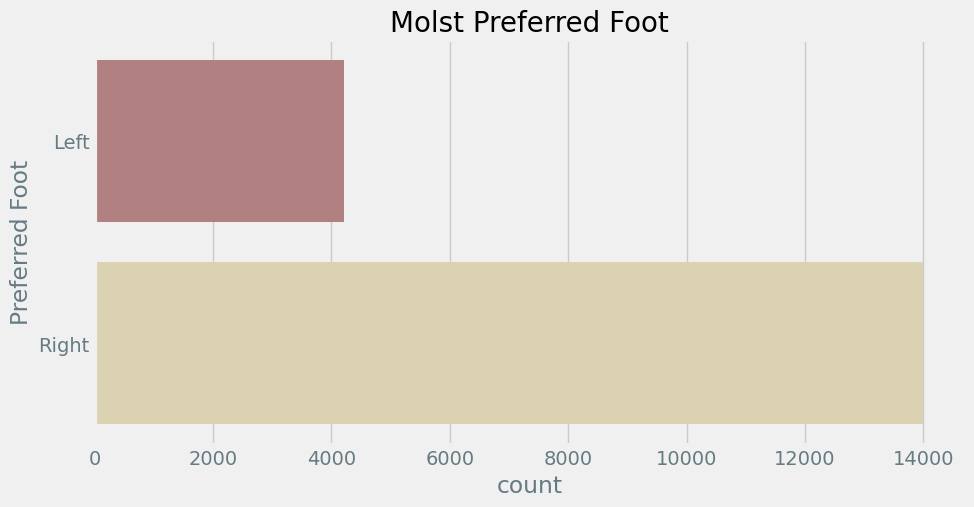

In [188]:
plt.rcParams['figure.figsize']=(10,5)
sns.countplot(data['Preferred Foot'],palette='pink')
plt.title('Molst Preferred Foot',fontsize=20)
plt.show()

International reputation by reputation categories

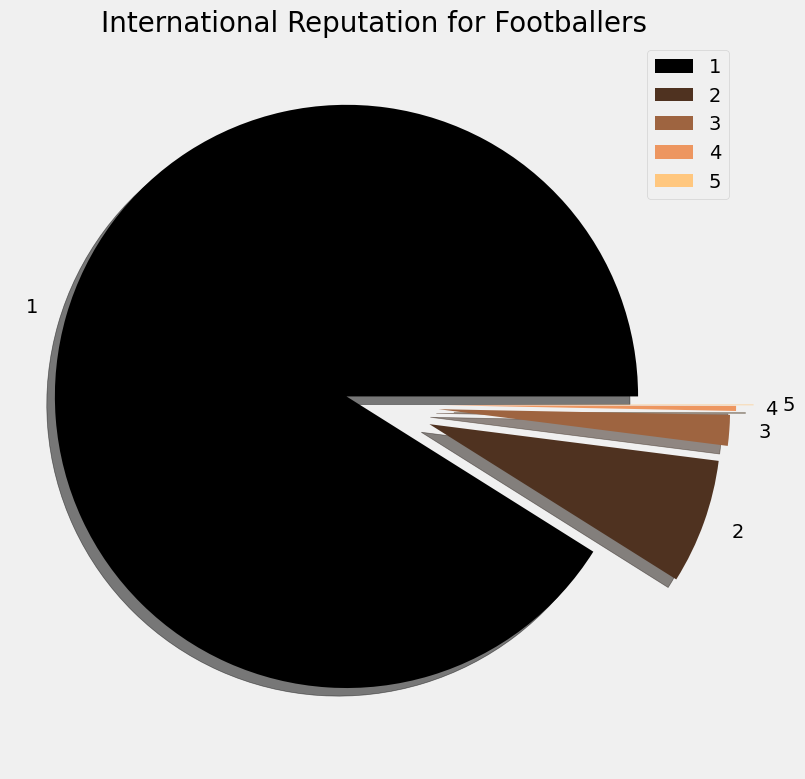

In [189]:
#plott international representation
sizes=data['International Reputation'].value_counts()
labels=[int(i) for i in range(1,len(sizes)+1)]
colors=plt.cm.copper(np.linspace(0,1,len(sizes)))
explode=[0.1,0.2,.22,0.24,0.3,]

plt.rcParams['figure.figsize']=(9,9)
plt.pie(sizes,labels=labels,colors=colors,explode=explode,shadow=True)
plt.title('International Reputation for Footballers',fontsize=20)
plt.legend()
plt.show()

international reputation by player

In [190]:
data[data['International Reputation']==5][['Name','Nationality',
    'Overall']].sort_values(by='Overall',
     ascending=False).style.background_gradient(cmap='magma')

,Name,Nationality,Overall
0,L. Messi,Argentina,94
1,Cristiano Ronaldo,Portugal,94
2,Neymar Jr,Brazil,92
7,L. Suárez,Uruguay,91
22,M. Neuer,Germany,89
109,Z. Ibrahimović,Sweden,85


look at ratings for players' week feet

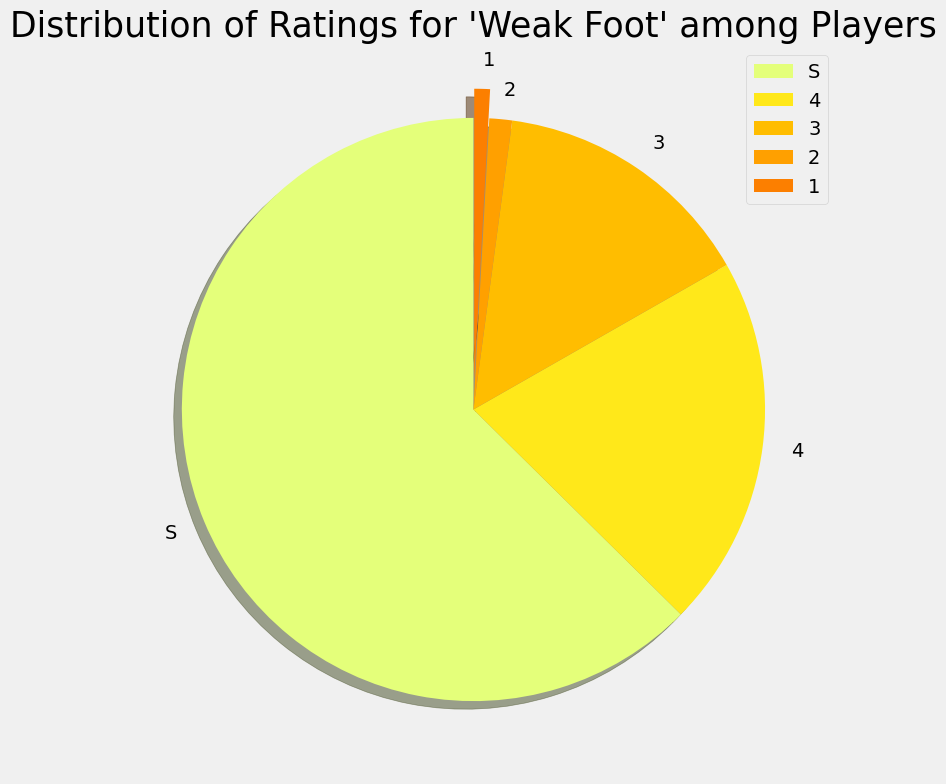

In [191]:
size=data['Weak Foot'].value_counts()
n=len(size)
labels=['S']+[str(i) for i in range(n-1,0,-1)]
colors=plt.cm.Wistia(np.linspace(0,1,n))
explode=[0 if i!=n-1 else 0.1 for i in range(n) ]

plt.pie(size,labels=labels,colors=colors,explode=explode,shadow=True,startangle=90)
plt.title('Distribution of Ratings for \'Weak Foot\' among Players',fontsize=25)
plt.legend()
plt.show()


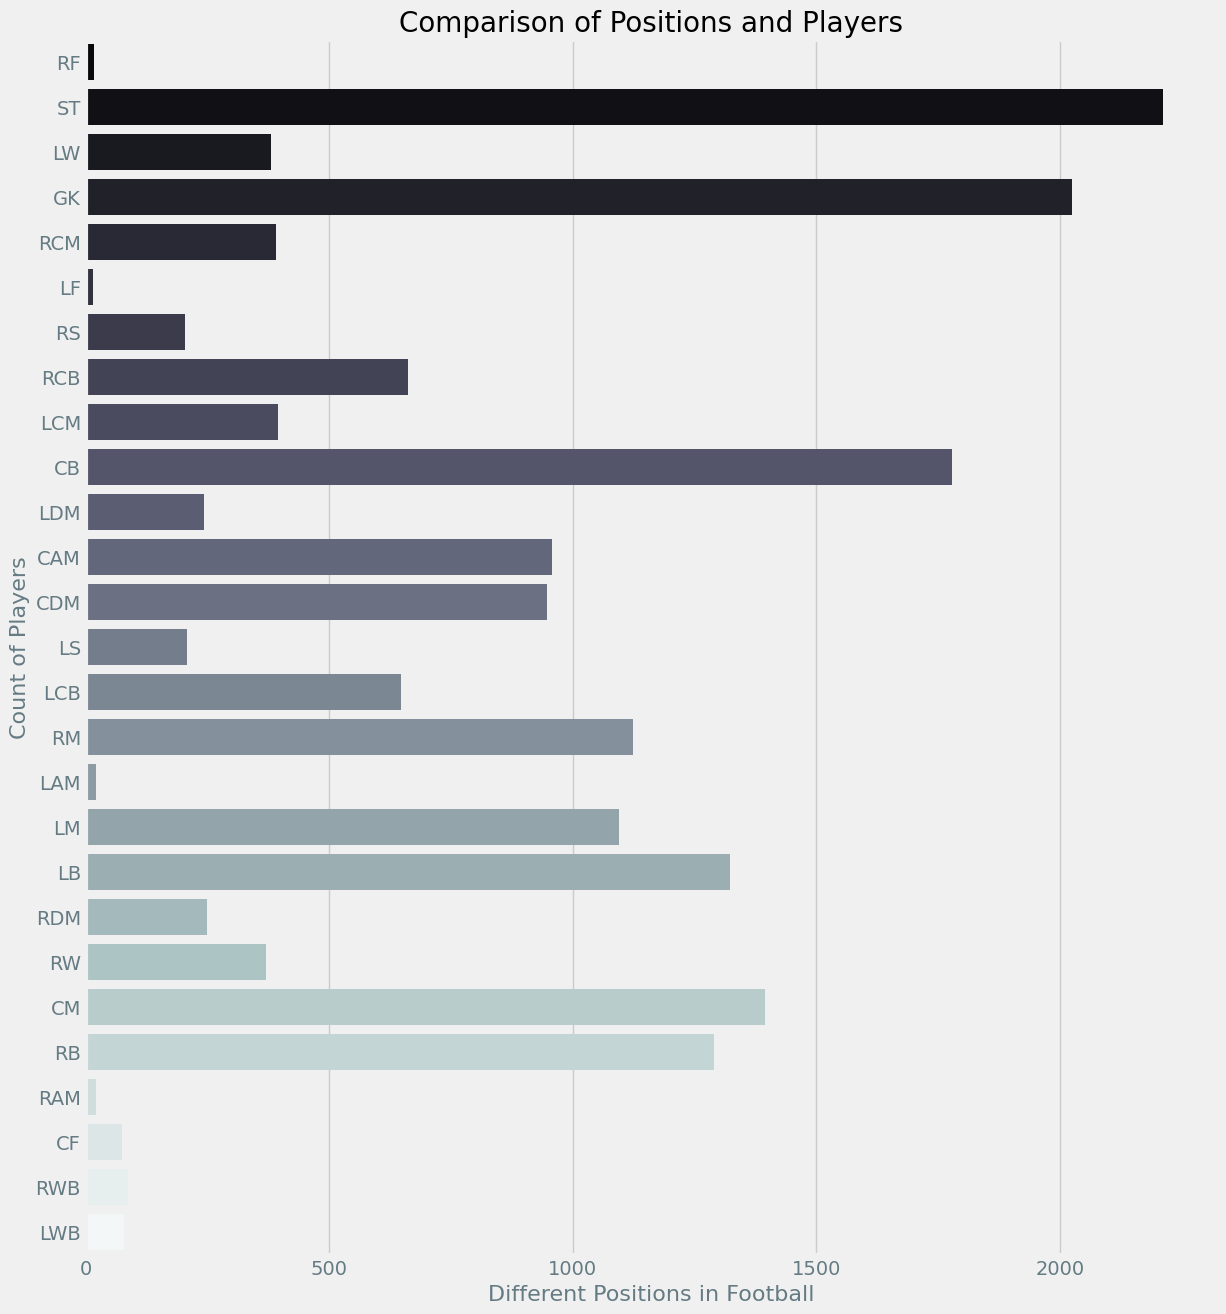

In [ ]:
#different positions acquired by the players
plt.figure(figsize=(13,15))
plt.style.use('fivethirtyeight')
ax= sns.countplot(y='Position',data=data,palette='bone')
ax.set_xlabel(xlabel='Different Positions in Football',fontsize=16)
ax.set_ylabel(ylabel='Count of Players',fontsize=16)
ax.set_title(label='Comparison of Positions and Players',fontsize=20)
plt.show()

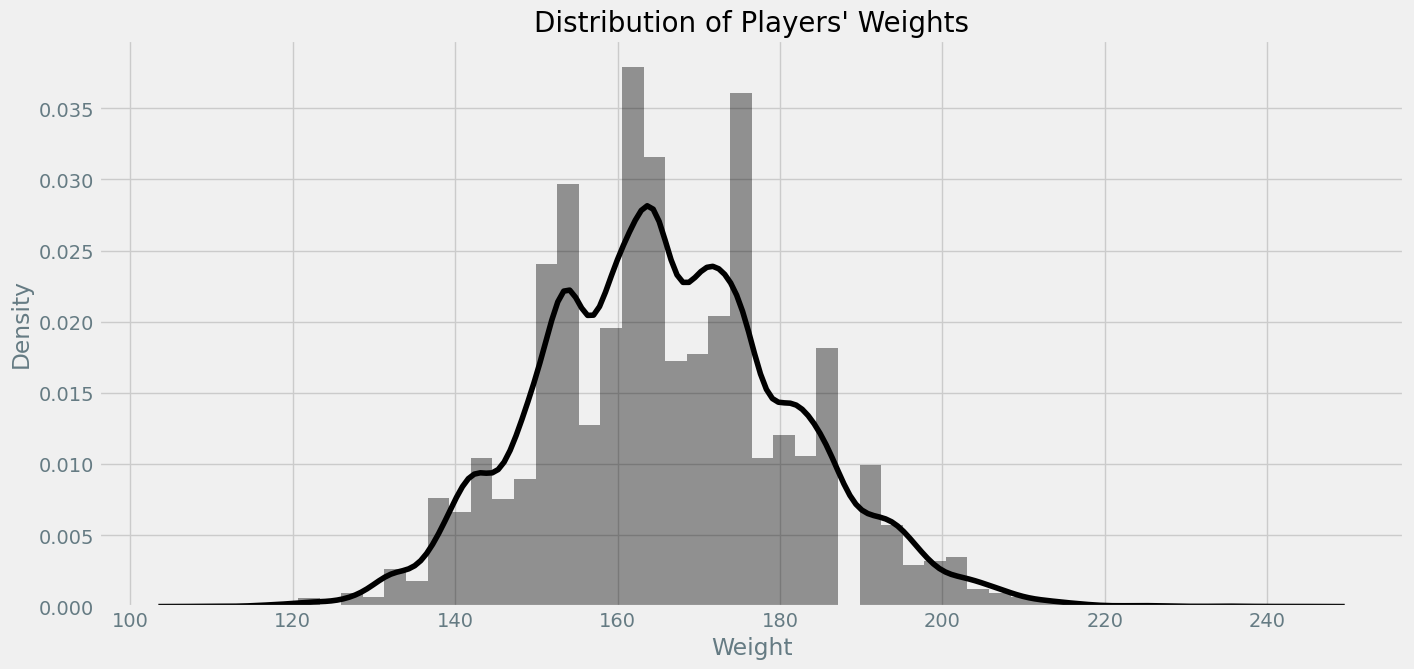

In [201]:
# func to clean the target weight data
def extract_value_from(value):
  out=value
  if isinstance(out,str):
    out=out.replace('lbs','')
  return float(out)

  #applying the function
data['Weight']=data['Weight'].apply(extract_value_from)

#plotting teh distribution
sns.distplot(data['Weight'],color = 'black')
plt.title('Distribution of Players\' Weights',fontsize=20)
plt.show()


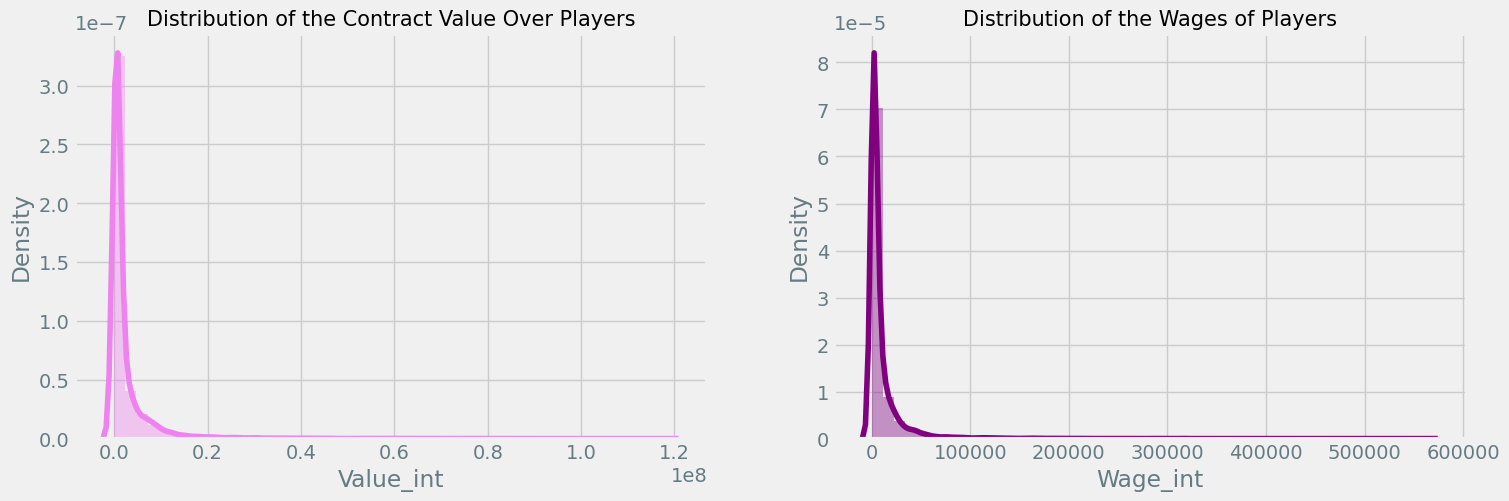

In [203]:
#applying the function
data['Value_int']=data['Value_int'].apply(extract_value_from)
data['Wage_int']=data['Wage_int'].apply(extract_value_from)

plt.rcParams['figure.figsize'] = (16,5)
plt.subplot(1,2,1)
sns.distplot(data['Value_int'],color = 'violet')
plt.title('Distribution of the Contract Value Over Players', fontsize=15)
plt.subplot(1,2,2)
sns.distplot(data['Wage_int'],color = 'purple')
plt.title('Distribution of the Wages of Players', fontsize=15)
plt.show()

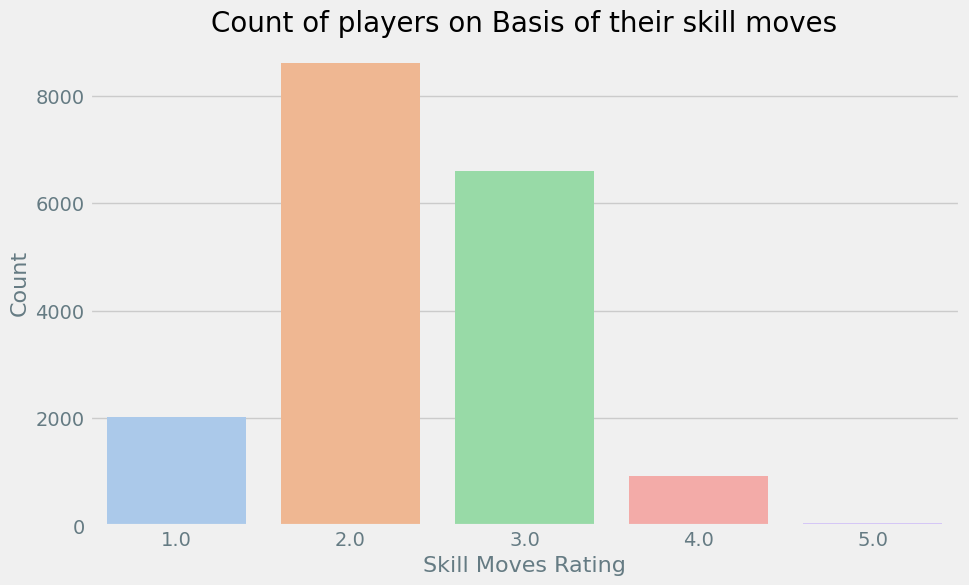

In [204]:
#Skill Moves of Players
plt.figure(figsize=(10,6))
ax = sns.countplot(x = 'Skill Moves',data=data, palette='pastel')
ax.set_xlabel(xlabel='Skill Moves Rating',fontsize=16)
ax.set_ylabel(ylabel='Count',fontsize=16)
ax.set_title(label="Count of players on Basis of their skill moves",fontsize=20)
plt.show()

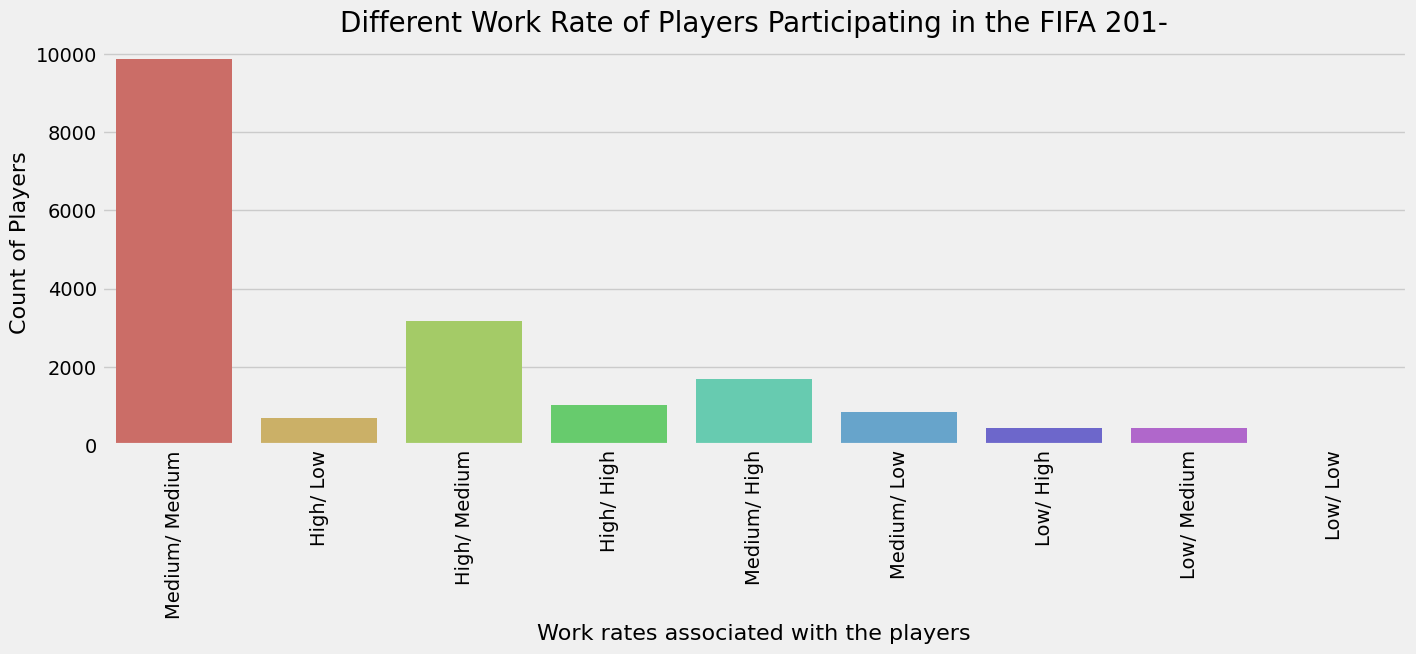

In [ ]:
# different work rate
plt.figure(figsize=(15,5))
plt.style.use('fivethirtyeight')

sns.countplot(x = 'Work Rate', data = data, palette = 'hls')
plt.title('Different Work Rate of Players Participating in the FIFA 201-',fontsize = 20)
plt.xlabel('Work rates associated with the players',fontsize = 16)
plt.ylabel('Count of Players' ,fontsize = 16)
plt.xticks(rotation=90)
plt.show()

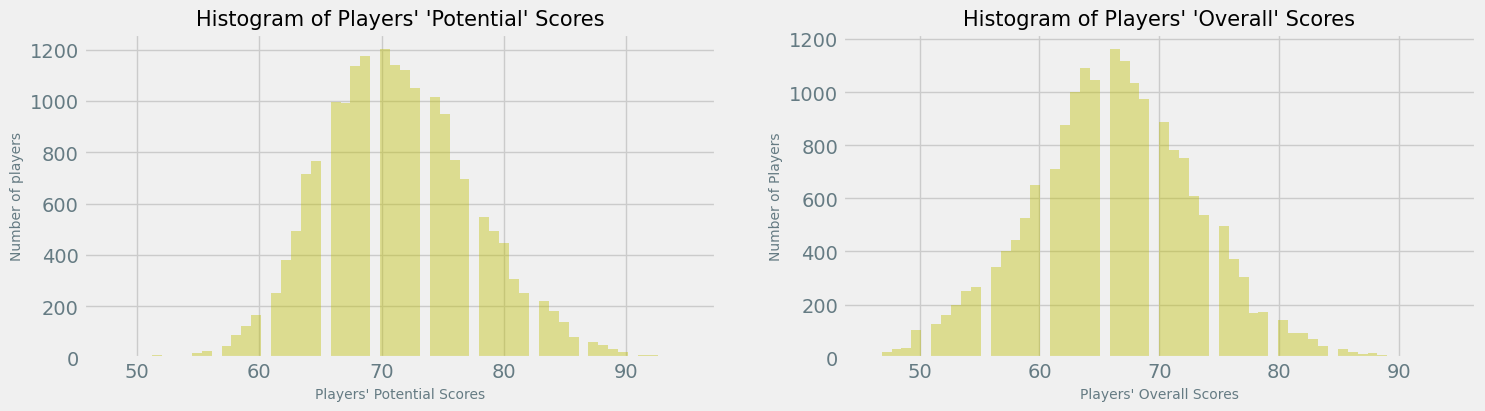

In [205]:
#to show different potential scores of the players participating in the FIFA 2019
plt.figure(figsize=(16,4))
plt.style.use('seaborn-v0_8-colorblind')

plt.subplot(1,2,1)
x=data['Potential']
ax=sns.distplot(x,bins=58,kde=False,color='y')
ax.set_xlabel(xlabel = "Players\' Potential Scores", fontsize=10)
ax.set_ylabel(ylabel = "Number of players",fontsize = 10)
ax.set_title(label = "Histogram of Players\' \'Potential\' Scores",fontsize = 15)
             
plt.subplot(1,2,2)
y = data['Overall']
ax=sns.distplot(y,bins=58,kde=False,color='y')
ax.set_xlabel(xlabel ="Players\' Overall Scores",fontsize =10)
ax.set_ylabel(ylabel = "Number of Players",fontsize = 10)
ax.set_title(label = "Histogram of Players\' \'Overall\' Scores",fontsize = 15)

plt.show()

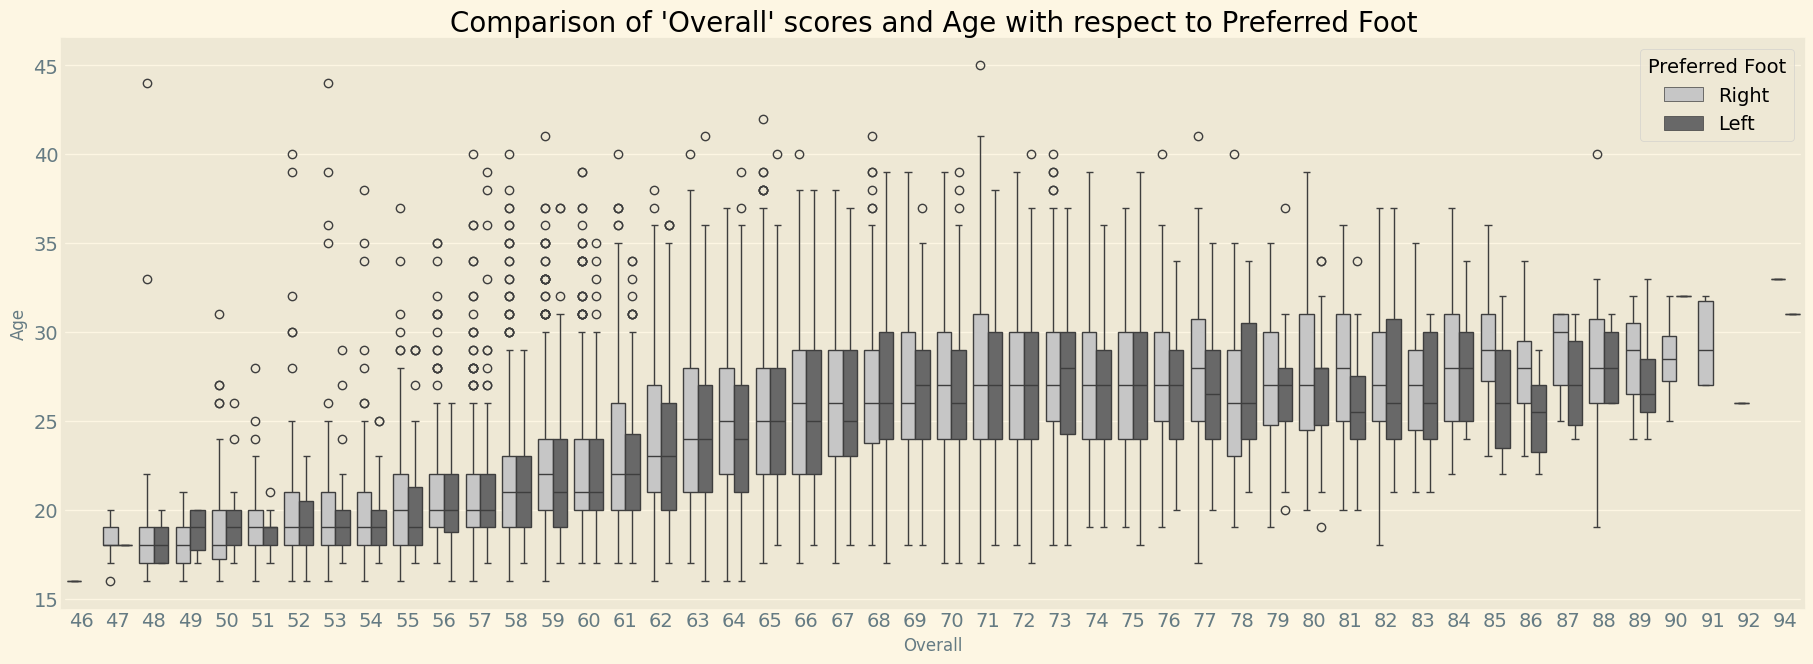

In [206]:

plt.rcParams['figure.figsize']=(20,7)
plt.style.use('Solarize_Light2')

sns.boxplot(x=data['Overall'],y=data['Age'],hue=data['Preferred Foot'],palette= 'Greys') #where data['Preferred Foot'].unique() returns array(['Left', 'Right'], dtype=object)
plt.title('Comparison of \'Overall\' scores and Age with respect to Preferred Foot',fontsize=20)
plt.show()


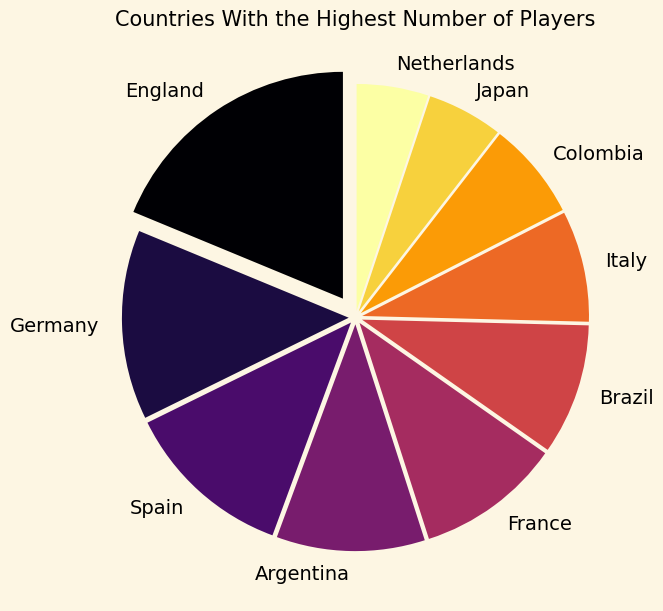

In [ ]:
n=10
data['Nationality'].value_counts().head(n).plot(kind='pie',
                    cmap='inferno',
                    startangle=90,                                                 
                    explode=[0.03 if i!=0 else 0.1 for i in range(0,n)])
plt.title('Countries With the Highest Number of Players',fontsize = 15)
plt.axis('off')
plt.show()

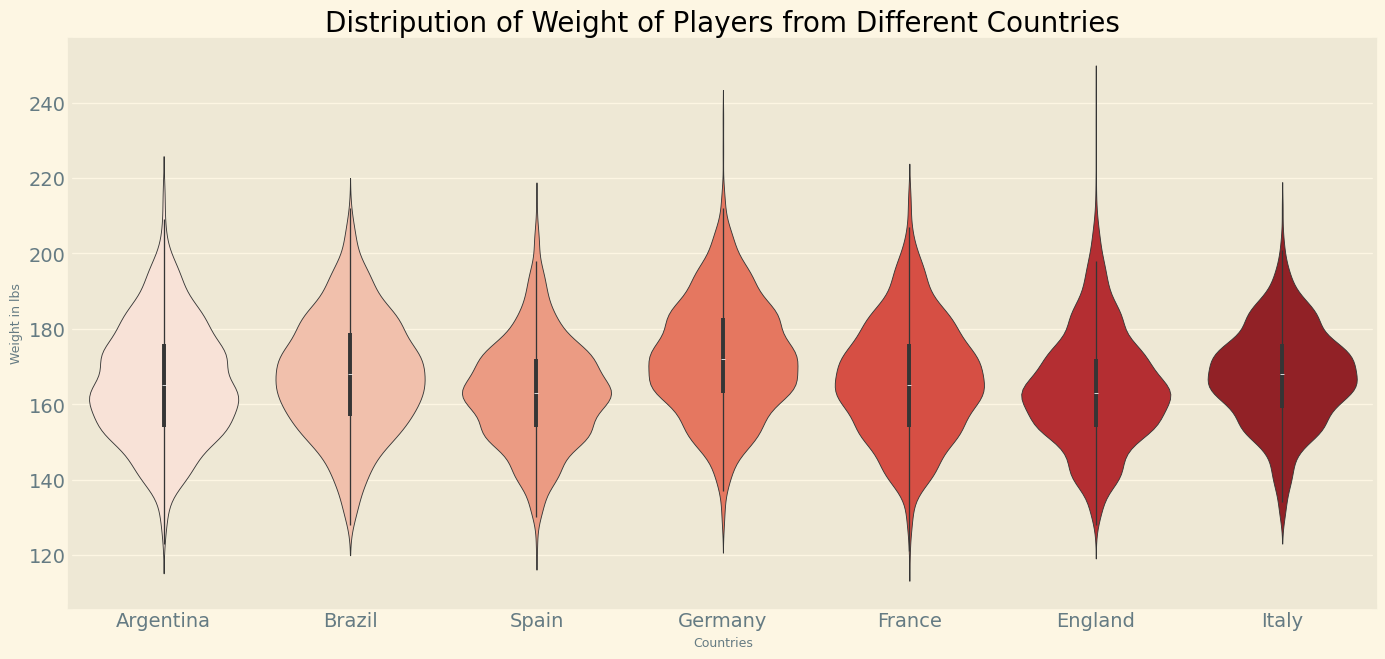

In [ ]:
# Every Nations' Player and their weights
some_countries = ('England','Germany','Spain','Argentina',
        'France','Brazil','Italy','Columbia',)
data_countries = data.loc[data['Nationality'].isin(some_countries) & data['Weight']]
plt.rcParams['figure.figsize']=(15,7)
ax = sns.violinplot(x=data_countries['Nationality'],y=data_countries['Weight'],palette = 'Reds')
ax.set_xlabel(xlabel='Countries',fontsize=9)
ax.set_ylabel(ylabel='Weight in lbs',fontsize=9)
ax.set_title(label = 'Distripution of Weight of Players from Different Countries',fontsize = 20)
plt.show()

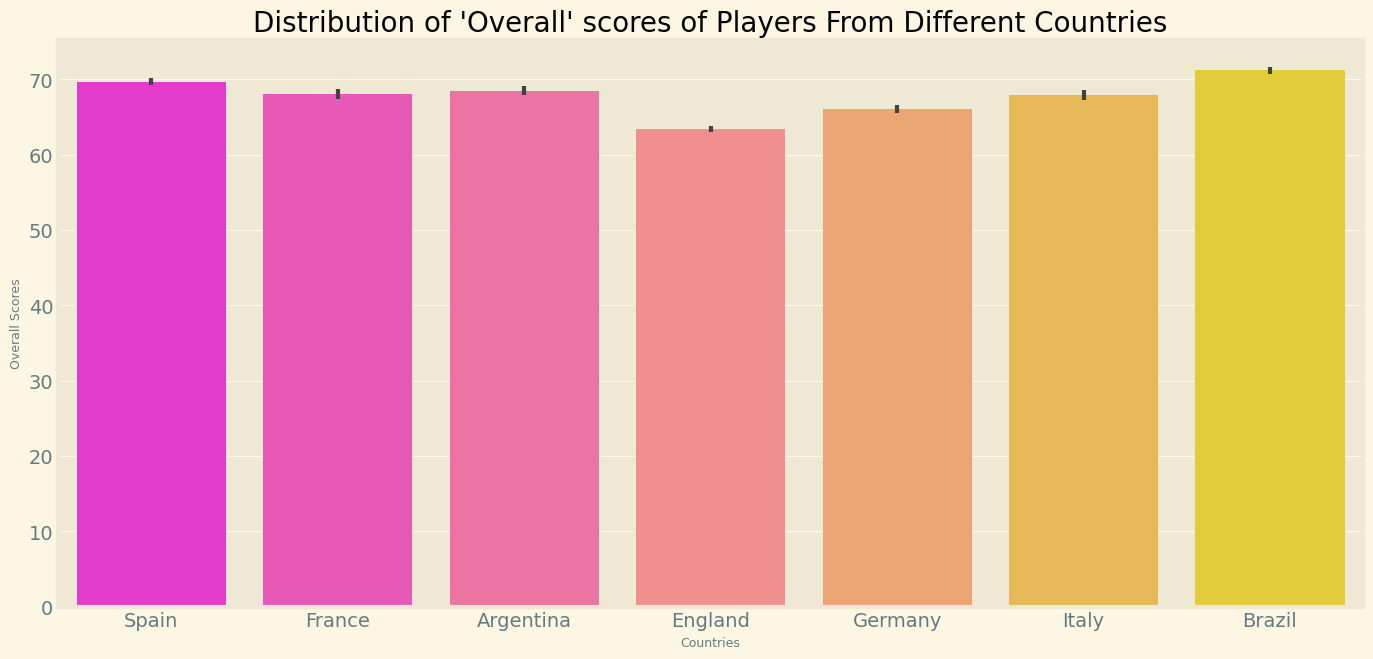

In [207]:
some_countries = ('England','Germany','Spain','Argentina','France',
                  'Brazil','Italy','Columbia')
data_countries = data.loc[data['Nationality'].isin(some_countries) & data['Overall']]
plt.rcParams['figure.figsize']=(15,7)
ax = sns.barplot(x=data_countries['Nationality'],y=data_countries['Overall'],palette = 'spring')
ax.set_xlabel(xlabel='Countries',fontsize=9)
ax.set_ylabel(ylabel='Overall Scores',fontsize=9)
ax.set_title(label= 'Distribution of \'Overall\' scores of Players From Different Countries',fontsize=20)
plt.show()

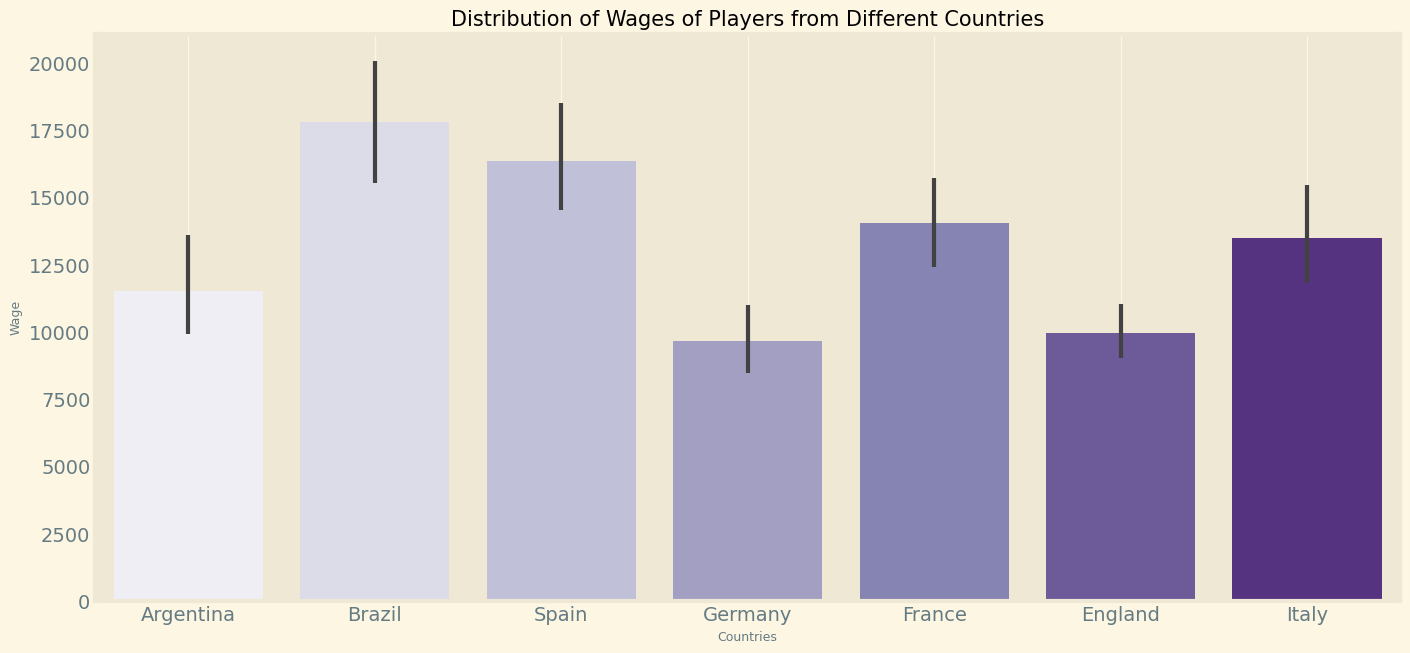

In [ ]:
some_countries = ('England','Germany','Spain','Argentina','France',
                  'Brazil','Italy','Columbia')
data_countries = data.loc[data['Nationality'].isin(some_countries)&data['Wage_int']]
plt.rcParams['figure.figsize']=(15,7)
ax = sns.barplot(x=data_countries['Nationality'],y=data_countries['Wage_int'],palette='Purples')
ax.set_xlabel(xlabel='Countries',fontsize=9)
ax.set_ylabel(ylabel='Wage',fontsize=9)
ax.set_title(label='Distribution of Wages of Players from Different Countries',fontsize=15)
plt.grid()
plt.show()

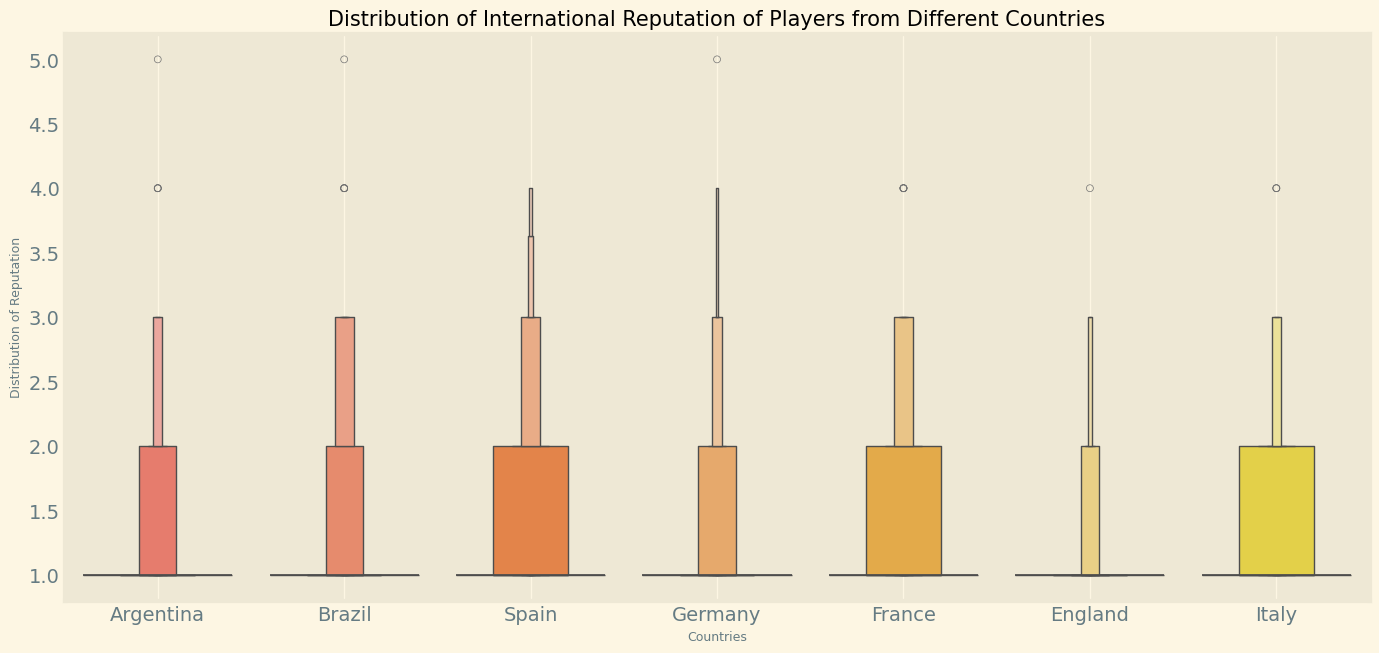

In [ ]:
#internation reputation
some_countries = ('England','Germany','Spain','Argentina','France',
                  'Brazil','Italy','Columbia')
data_countries = data.loc[data['Nationality'].isin(some_countries)& data['International Reputation']]
plt.rcParams['figure.figsize']=(15,7)
ax = sns.boxenplot(x=data_countries['Nationality'],y=data_countries['International Reputation'],palette='autumn')
ax.set_xlabel(xlabel='Countries',fontsize=9)
ax.set_ylabel(ylabel='Distribution of Reputation',fontsize=9)
ax.set_title(label='Distribution of International Reputation of Players from Different Countries',fontsize=15)
plt.grid()
plt.show()

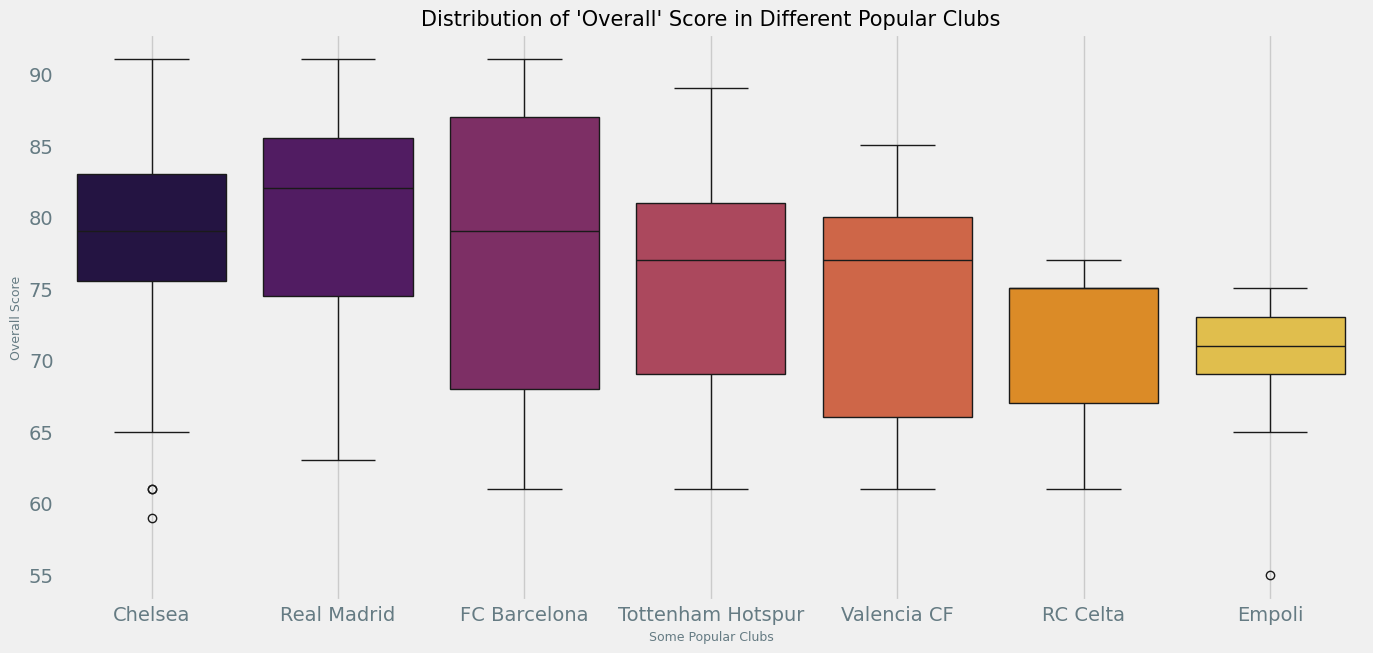

In [200]:

some_clubs = ('CD Legends','Southamptom','RC Celta','Empoli','Fortuna Dusseldorf','Manchestar City',
              'Tottenham Hotspur','FC Barcelona','Valencia CF','Chelsea','Real Madrid')
data_clubs = data.loc[data['Club'].isin(some_clubs)& data['Overall']]
plt.rcParams['figure.figsize']=(15,7)
ax = sns.boxplot(x=data_clubs['Club'],y=data_clubs['Overall'],palette='inferno')
ax.set_xlabel(xlabel='Some Popular Clubs',fontsize=9)
ax.set_ylabel(ylabel='Overall Score',fontsize=9)
ax.set_title(label='Distribution of \'Overall\' Score in Different Popular Clubs',fontsize=15)
plt.grid()
plt.show()

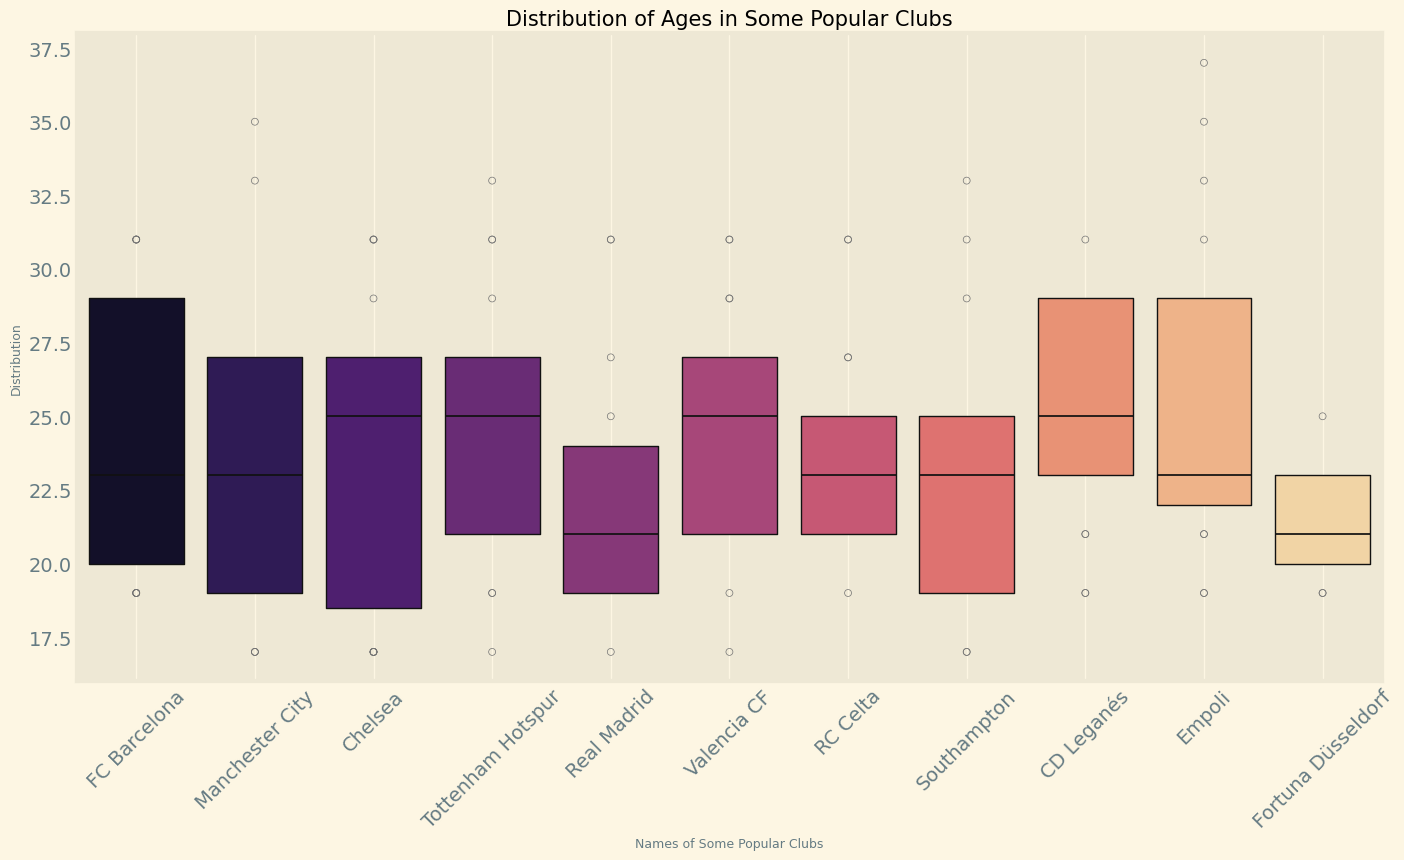

In [ ]:
some_clubs = ('CD Leganés','Southampton','RC Celta','Empoli','Fortuna Düsseldorf','Manchester City',
              'Tottenham Hotspur','FC Barcelona','Valencia CF','Chelsea','Real Madrid')
data_clubs = data.loc[data['Club'].isin(some_clubs)& data['Age']]
plt.rcParams['figure.figsize']=(15,8)
ax = sns.boxenplot(x=data_clubs['Club'],y=data_clubs['Age'],palette='magma')
ax.set_xlabel(xlabel='Names of Some Popular Clubs',fontsize=9)
ax.set_ylabel(ylabel='Distribution',fontsize=9)
ax.set_title(label='Distribution of Ages in Some Popular Clubs',fontsize=15)
plt.xticks(rotation=45)
plt.grid()
plt.show()

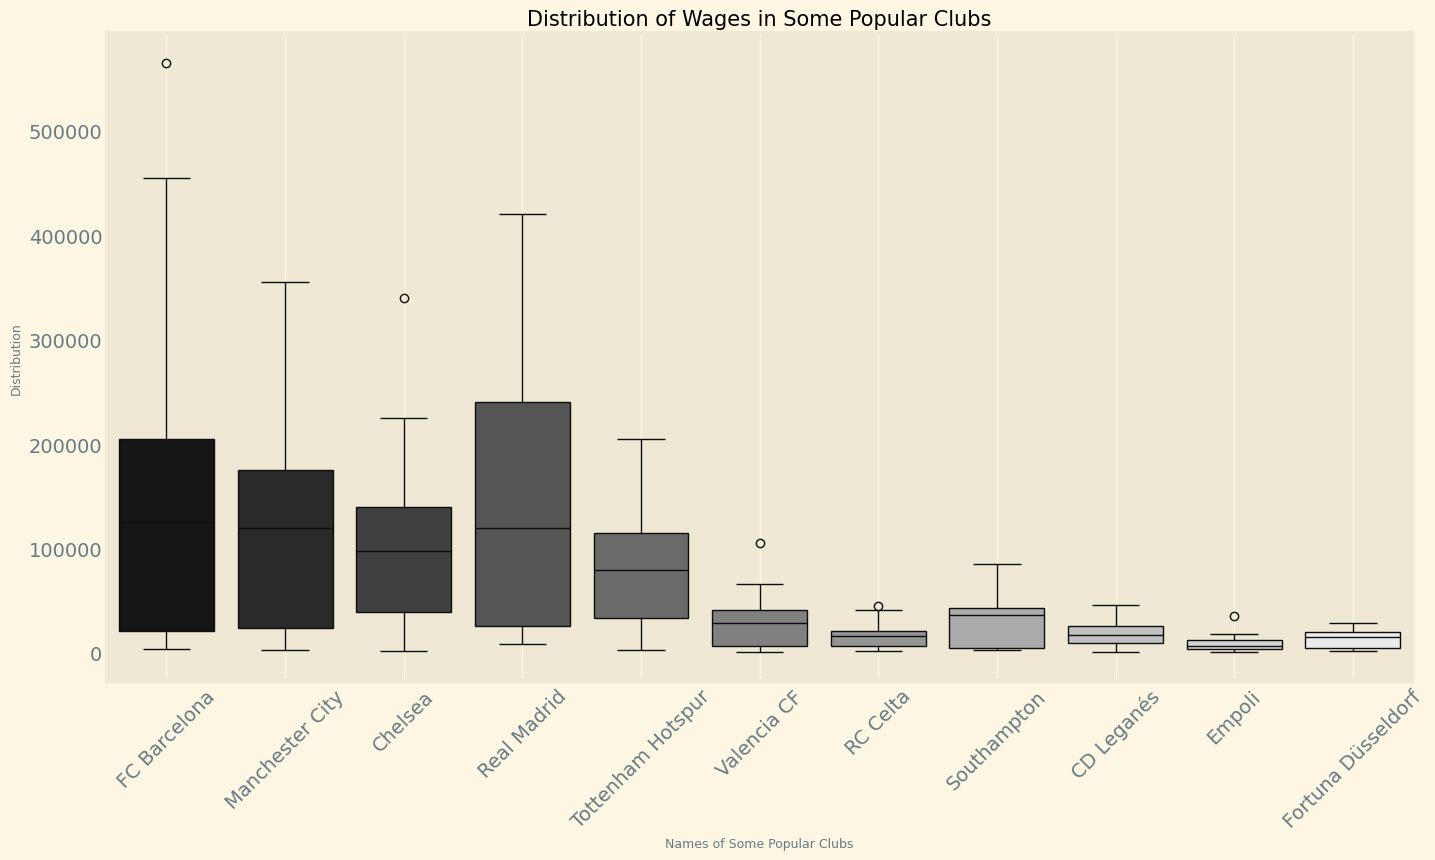

In [ ]:
some_clubs = ('CD Leganés','Southampton','RC Celta','Empoli','Fortuna Düsseldorf','Manchester City',
              'Tottenham Hotspur','FC Barcelona','Valencia CF','Chelsea','Real Madrid')
data_clubs = data.loc[data['Club'].isin(some_clubs)& data['Wage_int']]
plt.rcParams['figure.figsize']=(15,8)
ax = sns.boxplot(x=data_clubs['Club'],y=data_clubs['Wage_int'],palette='grey')
ax.set_xlabel(xlabel='Names of Some Popular Clubs',fontsize=9)
ax.set_ylabel(ylabel='Distribution',fontsize=9)
ax.set_title(label='Distribution of Wages in Some Popular Clubs',fontsize=15)
plt.xticks(rotation=45)
plt.grid()
plt.show()

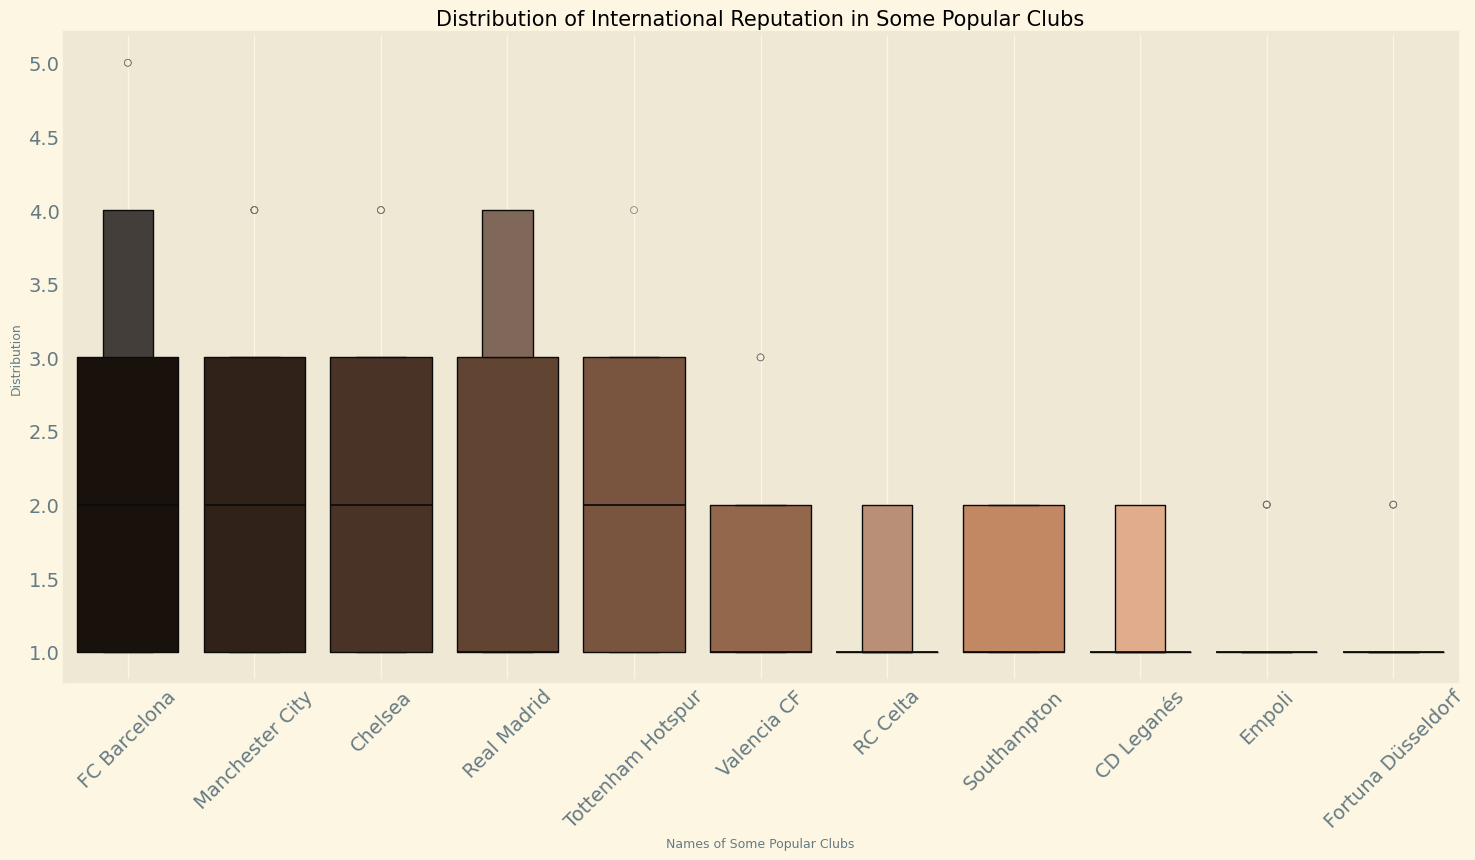

In [ ]:
some_clubs = ('CD Leganés','Southampton','RC Celta','Empoli','Fortuna Düsseldorf','Manchester City',
              'Tottenham Hotspur','FC Barcelona','Valencia CF','Chelsea','Real Madrid')
data_clubs = data.loc[data['Club'].isin(some_clubs)& data['International Reputation']]
plt.rcParams['figure.figsize']=(16,8)
ax = sns.boxenplot(x=data_clubs['Club'],y=data_clubs['International Reputation'],palette='copper')
ax.set_xlabel(xlabel='Names of Some Popular Clubs',fontsize=9)
ax.set_ylabel(ylabel='Distribution',fontsize=9)
ax.set_title(label='Distribution of International Reputation in Some Popular Clubs',fontsize=15)
plt.xticks(rotation=45)
plt.grid()
plt.show()

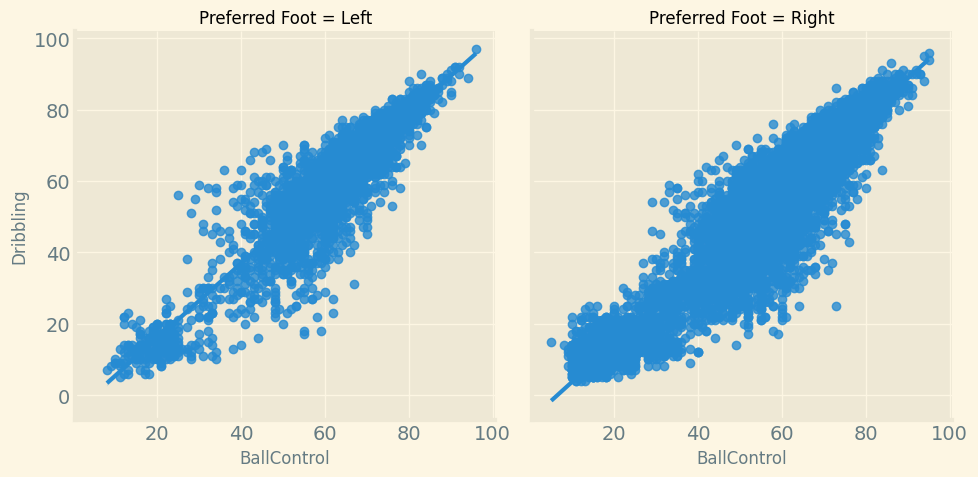

In [ ]:
#compare the performance of left-footed adn right-footed footballers
#ballcontrol vs dribbling

sns.lmplot(x='BallControl',y='Dribbling',data=data,col='Preferred Foot')
plt.show()

# Query Analysis

best player in each position and the player's age, club, and nationality  

In [ ]:
# best player per position with respect to age, club, and nationality
data.iloc[data.groupby('Position')['Overall'].idxmax()][['Position','Name','Age','Club',
                'Nationality','Overall']].sort_values(by='Overall',
                ascending=False).style.background_gradient(cmap='pink')

,Position,Name,Age,Club,Nationality,Overall
1,ST,Cristiano Ronaldo,33,Juventus,Portugal,94
0,RF,L. Messi,31,FC Barcelona,Argentina,94
2,LW,Neymar Jr,26,Paris Saint-Germain,Brazil,92
5,LF,E. Hazard,27,Chelsea,Belgium,91
7,RS,L. Suárez,31,FC Barcelona,Uruguay,91
4,RCM,K. De Bruyne,27,Manchester City,Belgium,91
3,GK,De Gea,27,Manchester United,Spain,91
8,RCB,Sergio Ramos,32,Real Madrid,Spain,91
12,CB,D. Godín,32,Atlético Madrid,Uruguay,90
11,LCM,T. Kroos,28,Real Madrid,Germany,90


## Most of the following cells have an interactive element and will require 'run all' under run cells options at the top.

Best player for each skill  

In [ ]:
# the features need to be run, they are in cells 18 and 19 ish
# analyze the skills of players
@interact
def skills(skills = ['Defending','General','Mental','Passing',
                     'Mobility','Power','Rating','Shooting'],score=89):
    return data[data[skills]>score][['Name','Nationality','Club','Overall',skills]].sort_values(by= skills,
           ascending=False).style.background_gradient(cmap='Blues')


interactive(children=(Dropdown(description='skills', options=('Defending', 'General', 'Mental', 'Passing', 'Mo…

A list to return the Top n players from each country

In [ ]:
@interact
def country(country=list(data['Nationality'].value_counts().index),n=5):
    return data[data['Nationality']==country][['Name','Position','Overall',
                                               'Potential']].sort_values(by='Overall',
                                                ascending=False).head(n).style.background_gradient(cmap='magma')

interactive(children=(Dropdown(description='country', options=('England', 'Germany', 'Spain', 'Argentina', 'Fr…

a list to return the Top n players from each club

In [ ]:
data['Jersey Number']=data['Jersey Number'].apply(lambda x: int(x))

In [ ]:
@interact
def club(club=list(data.loc[(data['Club']!=0)]['Club'].value_counts().index),n=5):
    return data[(data['Club']==club)][['Name','Jersey Number','Position','Overall','Nationality',
            'Age','Wage','Value','Contract Valid Until']].sort_values(by='Overall',
            ascending=False).head(n).style.background_gradient(cmap='inferno')

interactive(children=(Dropdown(description='club', options=('FC Barcelona', 'Valencia CF', 'Fortuna Düsseldorf…

Youngest Players from FIFA 2019  

In [ ]:
@interact
def young(Top_n_Youngest=5):
    return data[['Name','Age','Club','Nationality','Overall']].sort_values(by=['Age','Overall'],ascending=[True,False]).head(Top_n_Youngest).style.background_gradient(cmap='magma')

interactive(children=(IntSlider(value=5, description='Top_n_Youngest', max=15, min=-5), Output()), _dom_classe…

Eldest Players from FIFA 2019

In [ ]:
@interact
def eldest(Top_n_Eldest=5):
    return data[['Name','Age','Club','Nationality','Overall']].sort_values(by=['Age','Overall',
            ],ascending=False).head(Top_n_Eldest).style.background_gradient(cmap='Wistia')

interactive(children=(IntSlider(value=5, description='Top_n_Eldest', max=15, min=-5), Output()), _dom_classes=…

Players by Top Tenure

In [ ]:
#longest membership
@interact
def tenure(Top_n_Tenure=5):
    now= datetime.datetime.now()
    data['Joined_year']=data['Joined'].dropna().map(lambda x: x.split(',')[-1].split(' ')[-1])
    data['Years_Tenure'] = (data['Joined_year'].dropna().map(lambda x: now.year-int(x))).astype('int')
    membership = data[['Name','Club','Years_Tenure']].sort_values(by='Years_Tenure',
                      ascending=False).head(Top_n_Tenure)
    membership.set_index('Name',inplace=True)

    return membership.style.background_gradient(cmap='Reds')

interactive(children=(IntSlider(value=5, description='Top_n_Tenure', max=15, min=-5), Output()), _dom_classes=…

Tenure in 3 popular clubs

In [ ]:
@interact
def check(column='Years_Tenure',club=['FC Barcelona','Real Madrid','Chelsea'],membership=12):
    return data[(data[column]>=membership) & (data['Club'] == club)][['Name','Club','Years_Tenure',
                ]].sort_values(by='Years_Tenure',
                ascending=False).style.background_gradient(cmap='magma')

interactive(children=(Text(value='Years_Tenure', description='column'), Dropdown(description='club', options=(…

Defining features of players by position

In [ ]:
player_features=['Acceleration','Aggression','Agility','Balance','BallControl', 'Composure','Crossing','Dribbling','FKAccuracy','Finishing','GKDiving','GKHandling','GKKicking','GKPositioning','GKReflexes',
                 'HeadingAccuracy','Interceptions','Jumping','LongPassing','LongShots', 'Marking','Penalties']

# top 4 features for every position
'''
for i,val in data.groupby(data['Position'])[player_features].mean().iterrows():
    print('Position {}: {}, {}, {}'.format(i, *tuple(val.nlargest(4).index)))
    '''

temp_df=data.groupby("Position")[player_features].mean()
largest=temp_df.T
new_df=pd.DataFrame({'Position':['1st Essential Skill','2nd Essential Skill','3rd Essential Skill','4th Essential Skill']})
for col in largest:
    cells=largest[col].nlargest(4).index
    new_df[col]=[cells[0],cells[1],cells[2],cells[3]]

new_df=new_df.T.reset_index()
new_df.columns=[i for i in new_df.iloc[0,:]]
new_df=new_df.iloc[1:,:]
new_df.style.background_gradient(cmap='Blues')

,Position,1st Essential Skill,2nd Essential Skill,3rd Essential Skill,4th Essential Skill
1,CAM,Balance,Agility,Acceleration,BallControl
2,CB,Jumping,Aggression,HeadingAccuracy,Marking
3,CDM,Aggression,Jumping,Balance,BallControl
4,CF,Agility,Balance,Acceleration,Dribbling
5,CM,Balance,Agility,Acceleration,BallControl
6,GK,GKReflexes,GKDiving,GKPositioning,GKHandling
7,LAM,Agility,Balance,Acceleration,Dribbling
8,LB,Acceleration,Balance,Agility,Jumping
9,LCB,Jumping,Aggression,HeadingAccuracy,Marking
10,LCM,Balance,Agility,BallControl,LongPassing


Best Player by Fot

In [ ]:
@interact
def left_foot(Top_n_=5,foot=list(data['Preferred Foot'].value_counts().index)):
    return data[data['Preferred Foot'] == foot][['Name','Age','Club','Nationality','Preferred Foot',
                    'Overall']].sort_values(by='Overall', ascending=False).head(Top_n_).style.background_gradient(cmap='bone')

interactive(children=(IntSlider(value=5, description='Top_n_', max=15, min=-5), Dropdown(description='foot', o…

the most expensive players whose contracts are going to expire soon

In [208]:
@interact
def expensive_and_leaving(Top_n=5):
    def edge(val):
        if len(val)<=4: return 'Jan, 1, '+val
    df_exp=data.copy()
    #df_exp['date_sorter']=df_exp['Contract Valid Until'].apply(lambda x: edge(x))
    df_exp=df_exp.sort_values(by=['Contract Valid Until','Wage'], ascending=[True,False])[['Name','Club','Jersey Number','Position', 'Wage','Contract Valid Until','Value']]
    return df_exp.head(Top_n)


interactive(children=(IntSlider(value=5, description='Top_n', max=15, min=-5), Output()), _dom_classes=('widge…

create features for an overall player report based on the top percentile of each player for each category

In [209]:
@interact
def top_n(Top_Reputations=10):


    #get player percentiles for athleticism, Offense, Goalkeeping, Defense, international rep,
    data['International Reputation Top Percentile']=round(data['International Reputation'].rank(pct=True),4)*100
    data['Athleticism']=data[['Stamina', 'Strength', 'Vision','Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'Jumping', ]].apply(lambda x: x['Stamina']+ x['Strength']+ x['Vision']+ x['Acceleration']+ x['SprintSpeed']+ x['Agility']+ 
                            x['Reactions']+ x['Balance']+ x['Jumping'],axis=1)
    data['Athleticism Top Percentile']=round(data['Athleticism'].rank(pct=True),4)*100
    data['Offense']=data[['Skill Moves','Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl','ShotPower','LongShots',]].apply(lambda x: x['Skill Moves']+
                        x['Crossing']+x['Finishing']+x['HeadingAccuracy']+x['ShortPassing']+x['Volleys']+x['Dribbling']+x['Curve']+x['FKAccuracy']+x['LongPassing']+x['BallControl']+x['ShotPower']+x['LongShots'],axis=1)
    data['Offense Top Percentile']=round(data['Offense'].rank(pct=True),4)*100
    data['Goalkeeping']=data[['GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes',]].apply(lambda x: x['GKDiving']+x['GKHandling']+x['GKKicking']+x['GKPositioning']+x['GKReflexes'],axis=1)
    data['Goalkeeping Top Percentile']=round(data['Goalkeeping'].rank(pct=True),4)*100
    data['Defense']=data[['Interceptions', 'Positioning', 'StandingTackle', 'SlidingTackle','Marking' ]].apply(lambda x: x['Interceptions']+x['Positioning']+x['StandingTackle']+x['SlidingTackle']+x['Marking'],axis=1)
    data['Defense Top Percentile']=round(data['Defense'].rank(pct=True),4)*100

    return data[['Name','Club','Offense Top Percentile',
        'Defense Top Percentile','Athleticism Top Percentile',
        'Goalkeeping Top Percentile','International Reputation Top Percentile',
        'Wage']].sort_values(by='International Reputation Top Percentile',ascending=False).head(Top_Reputations)

interactive(children=(IntSlider(value=10, description='Top_Reputations', max=30, min=-10), Output()), _dom_cla…

compare Indian players with Russian players

,Nationality,Offense,Defense,Goalkeeping,Athleticism
0,India,499.066667,196.166667,83.133333,538.533333
1,Russia,631.721519,244.493671,104.848101,564.924051


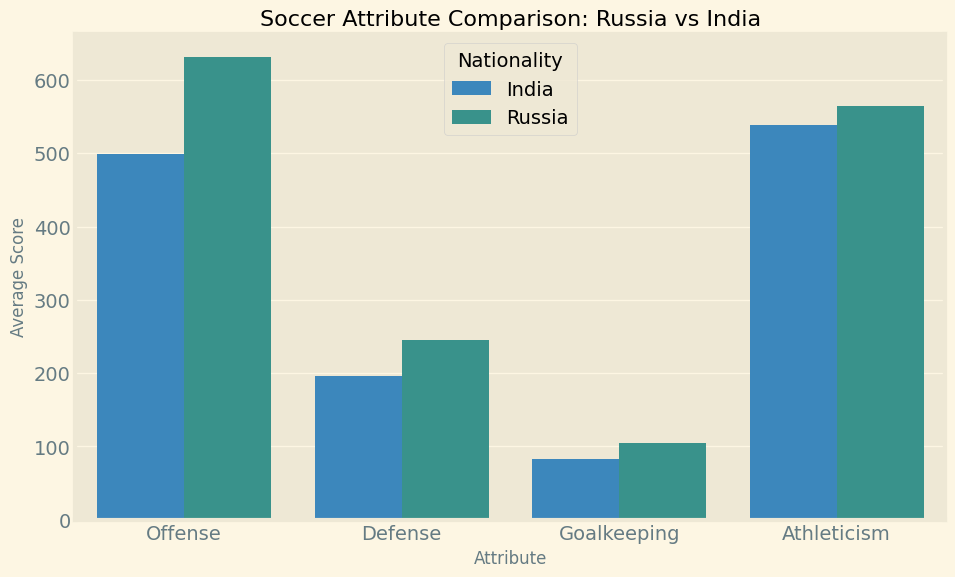

In [211]:
filtered_df=data.loc[(data['Nationality']=='Russia')|(data['Nationality']=='India')]
fi_df=filtered_df[['Name','Nationality','Club','Athleticism','Offense','Goalkeeping','Defense','International Reputation']].sort_values(by='International Reputation',ascending=False)
grouped=fi_df.groupby(['Nationality']).agg({'Offense':'mean','Defense':'mean','Goalkeeping':'mean','Athleticism':'mean'}).sort_values(by='Offense').reset_index()
display(grouped)
# Melt the DataFrame for easier plotting
grouped_melted = grouped.melt(id_vars=['Nationality'], var_name='Category', value_name='Score')

# Create a grouped barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Score', hue='Nationality', data=grouped_melted)

# Formatting
plt.title("Soccer Attribute Comparison: Russia vs India")
plt.xlabel("Attribute")
plt.ylabel("Average Score")
plt.legend(title="Nationality")

# Show the plot
plt.show()

most popular and under 20 years old

In [212]:
@interact  
def popular(n_most_popular=5):
    return data.loc[data['Age']<20][['Name','Age','Club','Jersey Number','Nationality','International Reputation']].sort_values(by='International Reputation',ascending=False).head(n_most_popular)

interactive(children=(IntSlider(value=5, description='n_most_popular', max=15, min=-5), Output()), _dom_classe…